# IDS Stage 1 - Adapted for nDPI CSV Format
Détection d'anomalies sur données de flux réseau nDPI

In [2]:
%matplotlib inline
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np
import seaborn as sns

from sklearn.preprocessing import RobustScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

import tensorflow as tf
from tensorflow.keras.models import Model
from tensorflow.keras.layers import Input, Dense
from tensorflow.keras.callbacks import EarlyStopping

import warnings
warnings.filterwarnings('ignore')

pd.set_option('display.max_columns', None)
sns.set(style="darkgrid")

I0000 00:00:1773181868.273629  235791 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.
I0000 00:00:1773181868.317402  235791 cpu_feature_guard.cc:227] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.
I0000 00:00:1773181869.499848  235791 cudart_stub.cc:31] Could not find cuda drivers on your machine, GPU will not be used.


## 1. LOAD DATA

In [3]:
# =========================
# ======= DATA LOAD =======
if len(X_tr) > MAX_TRAIN:
    idx = np.random.choice(len(X_tr), MAX_TRAIN, replace=False)
    X_tr_sub = X_tr[idx]
# =========================
TRAIN_PATH = "data/vertx_realtime_normaltraffic_20260204_3_000_000.csv"
# TEST_PATH  = "data/vertx_realtime_normaltraffic_20260203.csv"
TEST_PATH  = "data/vertx_flows_HPINGTraffic_20260204.csv"

train = pd.read_csv(TRAIN_PATH)
test  = pd.read_csv(TEST_PATH)

print(f"✅ Train: {train.shape[0]} rows × {train.shape[1]} columns")
print(f"✅ Test:  {test.shape[0]} rows × {test.shape[1]} columns")

NameError: name 'X_tr' is not defined

In [3]:
# Aperçu des données
print("\n📊 Premières lignes du dataset d'entraînement:")
train.head()


📊 Premières lignes du dataset d'entraînement:


,id,flowKey,firstSeen,lastSeen,srcIp,dstIp,srcPort,dstPort,protocol,bytes,packets,packetSummaries,treatmentDelay,durationMs,reasonOfFlowEnd,minPacketLength,maxPacketLength,meanPacketLength,stddevPacketLength,bytesPerSecond,packetsPerSecond,totalBytesUpstream,totalBytesDownstream,totalPacketsUpstream,totalPacketsDownstream,ratioBytesUpDown,ratioPacketsUpDown,flowDurationMs,interArrivalTimeMean,interArrivalTimeStdDev,interArrivalTimeMin,interArrivalTimeMax,flowSymmetry,synRate,finRate,rstRate,ackRate,pshRate,synCount,finCount,rstCount,ackCount,pshCount,tcpFraction,udpFraction,otherFraction,appProtocolBytes,appProtocol,riskLevel,riskMask,riskLabel,riskSeverity,ndpiFlowPtr,srcCountry,dstCountry,srcDomain,dstDomain,srcOrg,dstOrg
0,31d017fa-322a-4034-9c54-e99fc5ca06ca,10.180.137.66_172.64.154.211_41086_443_TCP,22557-01-13 23:40:3.2480000007,22557-01-13 23:40:4.3030000000,10.180.137.66,172.64.154.211,41086.0,443.0,TCP,132,2,{'P_10.180.137.66_172.64.154.211_TCP_ACK_64966...,"{15,16}",3055,Inactivity Timeout,66,66,66.0,0.000000,43.207855,0.654664,132.0,0.0,2.0,0.0,1.000000,1.0,3055.0,3055.00000,NaN,3055.0,3055.0,0.000000,0.0,0.00,0.5,1.0,0.00,0,0,1,2,0,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660475763680,NaN,NaN,NaN,NaN,NaN,NaN
1,f892c42b-ff89-41f2-9d64-bb13932f3922,10.162.8.10_10.180.137.66_53_47045_UDP,22565-04-05 05:37:3.9130000008,22565-04-05 05:37:3.9130000008,10.162.8.10,10.180.137.66,53.0,47045.0,UDP,149,1,{'P_10.162.8.10_10.180.137.66_UDP__64992362985...,{7},0,Inactivity Timeout,149,149,149.0,NaN,0.000000,0.000000,149.0,0.0,1.0,0.0,1.000000,1.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660871555872,NaN,NaN,NaN,NaN,NaN,NaN
2,b9cf61eb-4031-414f-ac42-38fe4cc346a8,10.162.8.10_10.180.137.66_53_35096_UDP,22565-04-10 00:58:0.8140000003,22565-04-10 00:58:0.5030000006,10.180.137.66,10.162.8.10,35096.0,53.0,UDP,254,2,{'P_10.180.137.66_10.162.8.10_UDP__64992404508...,"{12,12}",2689,Inactivity Timeout,85,169,127.0,59.396970,94.458910,0.743771,85.0,169.0,1.0,1.0,0.502959,1.0,2689.0,2689.00000,NaN,2689.0,2689.0,0.502959,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130660062943904,NaN,NaN,NaN,NaN,NaN,NaN
3,bd08a5c3-a738-42d3-ac34-0e4cdb50cc14,10.180.137.66_140.82.114.5_40238_443_TCP,22565-11-14 08:59:4.2940000004,22565-11-14 08:59:4.5340000005,140.82.114.5,10.180.137.66,443.0,40238.0,TCP,264,4,{'P_140.82.114.5_10.180.137.66_TCP_FIN_6499429...,"{15,16,16,16}",1240,Inactivity Timeout,54,90,66.0,16.970562,212.903230,3.225807,156.0,108.0,2.0,2.0,1.444444,1.0,1240.0,413.33334,269.61887,159.0,696.0,0.692308,0.0,0.25,0.5,0.5,0.25,0,1,2,2,1,1.0,0.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130661073369904,NaN,NaN,NaN,NaN,NaN,NaN
4,bd9d945d-4f0b-41dd-b6d7-b125ad617196,10.162.8.10_10.180.137.66_53_35068_UDP,22571-08-22 14:09:0.8060000004,22571-08-22 14:09:0.8060000004,10.162.8.10,10.180.137.66,53.0,35068.0,UDP,148,1,{'P_10.162.8.10_10.180.137.66_UDP__65012497254...,{19},0,Inactivity Timeout,148,148,148.0,NaN,0.000000,0.000000,148.0,0.0,1.0,0.0,1.000000,1.0,0.0,0.00000,0.00000,0.0,0.0,0.000000,0.0,0.00,0.0,0.0,-1.00,0,0,0,0,0,0.0,1.0,0.0,0.0,nDPI not initialized,-1,-1,{'No risk'},No risk,130662284939168,NaN,NaN,NaN,NaN,NaN,NaN


In [4]:
# Informations sur les colonnes
print("\n📋 Informations sur les colonnes:")
train.info()


📋 Informations sur les colonnes:
<class 'pandas.DataFrame'>
RangeIndex: 2100808 entries, 0 to 2100807
Data columns (total 59 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   id                      str    
 1   flowKey                 str    
 2   firstSeen               str    
 3   lastSeen                str    
 4   srcIp                   str    
 5   dstIp                   str    
 6   srcPort                 float64
 7   dstPort                 float64
 8   protocol                str    
 9   bytes                   int64  
 10  packets                 int64  
 11  packetSummaries         str    
 12  treatmentDelay          str    
 13  durationMs              int64  
 14  reasonOfFlowEnd         str    
 15  minPacketLength         int64  
 16  maxPacketLength         int64  
 17  meanPacketLength        float64
 18  stddevPacketLength      float64
 19  bytesPerSecond          float64
 20  packetsPerSecond        float64
 21  totalByt

## 2. FEATURE SELECTION - Features nDPI pertinentes

In [5]:
# =========================
# ======= FEATURES =======
# =========================
BASE_FEATURES = [
    'bytes', 'packets', 'minPacketLength', 'maxPacketLength',
    'meanPacketLength', 'stddevPacketLength', 'bytesPerSecond', 'packetsPerSecond',
    'totalBytesUpstream', 'totalBytesDownstream', 'totalPacketsUpstream',
    'totalPacketsDownstream', 'ratioBytesUpDown', 'ratioPacketsUpDown',
    'flowDurationMs', 'interArrivalTimeMean', 'interArrivalTimeStdDev',
    'interArrivalTimeMin', 'interArrivalTimeMax', 'flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'synCount', 'finCount', 'rstCount', 'ackCount', 'pshCount',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

DERIVED_FEATURES = [
    'avgPacketIntervalMs',
    'synFinDiff',
    'ackRatePerMs',
    'iatMaxToMeanRatio'
]

COLUMNS_TO_DROP = [
    'id', 'flowKey', 'firstSeen', 'lastSeen', 'srcIp', 'dstIp',
    'srcPort', 'dstPort', 'packetSummaries', 'treatmentDelay',
    'reasonOfFlowEnd', 'appProtocolBytes', 'appProtocol',
    'riskLevel', 'riskMask', 'riskLabel', 'riskSeverity',
    'ndpiFlowPtr', 'srcCountry', 'dstCountry', 'srcDomain',
    'dstDomain', 'srcOrg', 'dstOrg', "durationMs",'ratioBytesUpDown', 'ratioPacketsUpDown','flowSymmetry',
    'synRate', 'finRate', 'rstRate', 'ackRate', 'pshRate',
    'tcpFraction', 'udpFraction', 'otherFraction'
]

ALL_FEATURES = BASE_FEATURES + DERIVED_FEATURES

print(f"✅ Total features: {len(ALL_FEATURES)}")
print(f"✅ Features to drop: {len(COLUMNS_TO_DROP)}")

✅ Total features: 37
✅ Features to drop: 36


## 3. DATA PREPROCESSING

In [ ]:
# =========================
# ===== PREPROCESS ========
# =========================
def preprocess(df):
    df = df.copy()

    # Drop inutiles
    for col in COLUMNS_TO_DROP:
        if col in df.columns:
            df.drop(columns=[col], inplace=True)

    # Convertir en numérique
    for col in BASE_FEATURES:
        if col not in df.columns:
            df[col] = 0
        df[col] = pd.to_numeric(df[col], errors='coerce')
    df[BASE_FEATURES] = df[BASE_FEATURES].fillna(0)

    # clip negatif
    for col in BASE_FEATURES:
        df[col] = df[col].clip(lower=0)

    # éviter division par zéro
    small = 1e-6
    safe = ['flowDurationMs', 'interArrivalTimeMean',
            'totalPacketsUpstream', 'totalPacketsDownstream']
    for col in safe:
        df[col] = df[col].replace(0, small)

    # features dérivées
    df['avgPacketIntervalMs'] = df['flowDurationMs'] / (df['totalPacketsUpstream'] + df['totalPacketsDownstream'] + small)
    df['synFinDiff'] = df['synCount'] - df['finCount']
    df['ackRatePerMs'] = df['ackCount'] / (df['flowDurationMs'] + small)
    df['iatMaxToMeanRatio'] = df['interArrivalTimeMax'] / (df['interArrivalTimeMean'] + small)

    for col in DERIVED_FEATURES:
        df[col] = pd.to_numeric(df[col], errors='coerce').fillna(0)

    df = df.replace([np.inf, -np.inf], 0)
    df = df.fillna(0)

    return df

train = preprocess(train)
test  = preprocess(test)

NameError: name 'train_benign_df' is not defined

## 5. FEATURE ENGINEERING & SCALING

In [10]:
from sklearn.svm import OneClassSVM
##########################################
# ===== FEATURES =========================
##########################################

X_train = train[ALL_FEATURES]
X_test  = test[ALL_FEATURES]

##########################################
# ===== SCALING ROBUSTE ==================
##########################################

# clip valeurs extrêmes
X_train_clip = X_train.clip(upper=1e8)
X_test_clip  = X_test.clip(upper=1e8)

# log transform
X_tr = np.log1p(X_train_clip)
X_te = np.log1p(X_test_clip)

# nettoyage
X_tr = np.nan_to_num(X_tr, posinf=0, neginf=0)
X_te = np.nan_to_num(X_te, posinf=0, neginf=0)

# robust scaling
robust = RobustScaler()
X_tr = robust.fit_transform(X_tr)
X_te = robust.transform(X_te)

# minmax pour SVM
mm = MinMaxScaler()
X_tr = mm.fit_transform(X_tr)
X_te = mm.transform(X_te)

print("Scaling terminé.")
print("NaN train:", np.isnan(X_tr).any())
print("Inf train:", np.isinf(X_tr).any())

Scaling terminé.
NaN train: False
Inf train: False


In [11]:
# =========================
# ===== DBSCAN ===========
# =========================
from sklearn.cluster import DBSCAN
X_tr_sample = X_tr
if X_tr.shape[0] > 100000:
    X_tr_sample = X_tr[np.random.choice(X_tr.shape[0], 10000, replace=False)]
    
    
db = DBSCAN(eps=0.5, min_samples=5, metric='euclidean')  # supprime n_jobs=-1
db.fit(X_tr_sample)
train_labels = db.labels_
train_anomalies = np.sum(train_labels == -1)
print("DBSCAN train anomalies (échantillon):", train_anomalies)


DBSCAN train anomalies (échantillon): 11


In [ ]:

##########################################
# ===== SOUS ÉCHANTILLON TRAIN ===========
##########################################

MAX_TRAIN = 120_000   # important pour ne pas tuer la RAM
if len(X_tr) > MAX_TRAIN:
    idx = np.random.choice(len(X_tr), MAX_TRAIN, replace=False)
    X_tr_sub = X_tr[idx]
else:
    X_tr_sub = X_tr

print("Train utilisé pour SVM:", len(X_tr_sub))


##########################################
# ===== ONE CLASS SVM ====================
##########################################

ocsvm = OneClassSVM(
    kernel="rbf",
    gamma="scale",
    nu=0.01    # % attendu max d'anomalies
)

print("Training OCSVM...")
ocsvm.fit(X_tr_sub)

##########################################
# ===== SCORING ==========================
##########################################

train_scores = ocsvm.decision_function(X_tr)
test_scores  = ocsvm.decision_function(X_te)

# seuil basé sur train normal
threshold = np.percentile(train_scores, 1)

train_pred = train_scores < threshold
test_pred  = test_scores  < threshold

print("\n===== ONE CLASS SVM =====")
print("Train anomalies:", train_pred.sum())
print("Test anomalies :", test_pred.sum())

print("Train score range:", train_scores.min(), train_scores.max())
print("Test score range :", test_scores.min(), test_scores.max())

Train utilisé pour SVM: 120000
Training OCSVM...

===== ONE CLASS SVM =====
Train anomalies: 14950
Test anomalies : 25
Train score range: -170.04969393013255 120.29113596682163
Test score range : -106.54128970542348 66.16371979289528


ValueError: 'c' argument has 10000 elements, which is inconsistent with 'x' and 'y' with size 2100808.

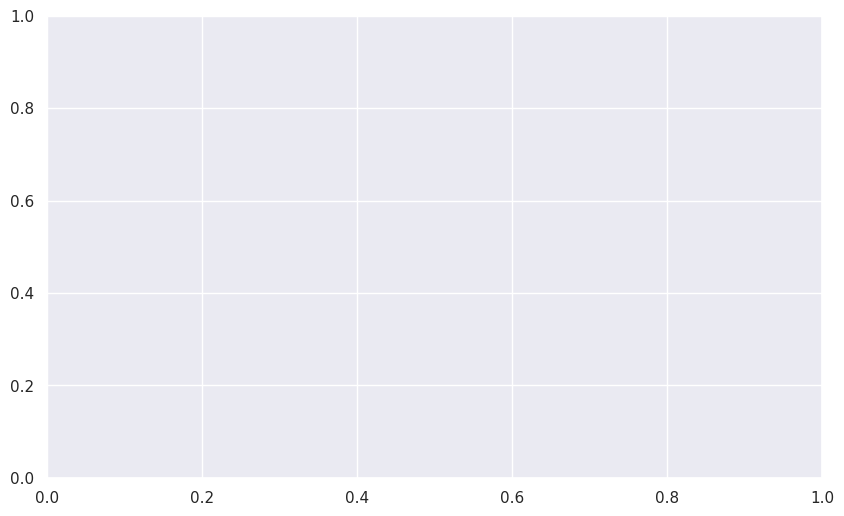

In [11]:

# =========================
# ===== VISUALISATION =====
# =========================
pca = PCA(n_components=2)
X_tr_2d = pca.fit_transform(X_tr)
X_te_2d = pca.transform(X_te)

plt.figure(figsize=(10,6))
plt.scatter(X_tr_2d[:,0], X_tr_2d[:,1], c=(train_labels==-1), cmap='coolwarm', alpha=0.5, label='Train anomalies')
plt.scatter(X_te_2d[:,0], X_te_2d[:,1], c=(test_dist>threshold), cmap='spring', alpha=0.5, marker='x', label='Test anomalies')
plt.title("DBSCAN - Détection d'anomalies")
plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.legend()
plt.show()

In [ ]:
print("\n" + "="*80)
print("📊 COMPARAISON DÉTAILLÉE Train vs Test (DONNÉES BRUTES)")
print("="*80)

# Afficher les différences en % pour toutes les features
print(f"\n{'Feature':<30} {'Train Mean':<15} {'Test Mean':<15} {'Diff %':<12}")
print("-" * 75)

differences_data = []
for feat in ALL_FEATURES:
    train_mean = X_train[feat].mean()
    test_mean = X_test[feat].mean()
    
    if train_mean != 0:
        diff_pct = abs(test_mean - train_mean) / abs(train_mean) * 100
    else:
        diff_pct = 0
    
    differences_data.append((feat, diff_pct, train_mean, test_mean))
    print(f"{feat:<30} {train_mean:<15.4f} {test_mean:<15.4f} {diff_pct:<12.2f}%")

# Trier par différence décroissante
differences_data.sort(key=lambda x: x[1], reverse=True)

print("\n" + "="*80)
print("🔴 TOP 10 FEATURES AVEC LES PLUS GRANDES DIFFÉRENCES:")
print("="*80)
for feat, diff_pct, train_mean, test_mean in differences_data[:10]:
    print(f"{feat:<30} Diff: {diff_pct:>8.2f}%")



📊 COMPARAISON DÉTAILLÉE Train vs Test (DONNÉES BRUTES)

Feature                        Train Mean      Test Mean       Diff %      
---------------------------------------------------------------------------
bytes                          7340.5156       66.5564         99.09       %
packets                        1.6803          1.0079          40.01       %
minPacketLength                3590.6895       65.5902         98.17       %
maxPacketLength                6251.3688       65.7010         98.95       %
meanPacketLength               4895.9679       65.6469         98.66       %
stddevPacketLength             1709.9744       0.0749          100.00      %
bytesPerSecond                 809.9639        0.0235          100.00      %
packetsPerSecond               0.2761          0.0003          99.90       %
totalBytesUpstream             4363.2431       66.2784         98.48       %
totalBytesDownstream           2976.9871       0.2781          99.99       %
totalPacketsUpstream 